# NeuroKin-3D: Dual-View Silhouette to XYZ Decoder

This notebook trains a dual-stream CNN to map two synchronized binary silhouettes to 3D end-effector coordinates (X, Y, Z). It includes a strict local overfit test and full training with visual validation.

In [1]:
import os
import sys
import time
import random
import importlib.util

def ensure_package(pkg):
    if importlib.util.find_spec(pkg) is None:
        import subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', '-q', 'install', pkg])

for pkg in ['numpy', 'matplotlib', 'torch', 'tqdm']:
    ensure_package(pkg)

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import trange

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

Device: cuda


## Dataset Configuration

Set the dataset path to the multi-view `.npz` file with `images_cam1`, `images_cam2`, and `ee_xyz`.

In [2]:
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

ROOT_CANDIDATES = [
    '/content/drive/MyDrive/robot_self_modelling',
    '/content/robot_self_modelling',
    os.path.abspath('.'),
]

REQUIRED_KEYS = {'images_cam1', 'images_cam2', 'ee_xyz'}

def has_required_keys(path):
    try:
        with np.load(path) as data:
            return REQUIRED_KEYS.issubset(set(data.files))
    except Exception:
        return False

def find_named_file(root, filename):
    data_dirs = [
        os.path.join(root, 'data', 'sim_data_multi_view'),
        os.path.join(root, 'data', 'sim_data'),
    ]
    for d in data_dirs:
        if not os.path.isdir(d):
            continue
        path = os.path.join(d, filename)
        if os.path.exists(path) and has_required_keys(path):
            return path
    return None

ROOT_DIR = None
TRAIN_PATH = None
TEST_PATH = None
for root in ROOT_CANDIDATES:
    if os.path.exists(root):
        train_candidate = find_named_file(root, 'mv_robo1_train.npz')
        test_candidate = find_named_file(root, 'mv_robo1_test.npz')
        if train_candidate and test_candidate:
            ROOT_DIR = root
            TRAIN_PATH = train_candidate
            TEST_PATH = test_candidate
            break

if ROOT_DIR is None:
    ROOT_DIR = os.path.abspath('.')

if TRAIN_PATH is None or TEST_PATH is None:
    raise FileNotFoundError('Train/test .npz not found. Expected mv_robo1_train.npz and mv_robo1_test.npz in data/sim_data_multi_view or data/sim_data.')

OUTPUT_DIR = os.path.join(ROOT_DIR, 'models')
os.makedirs(OUTPUT_DIR, exist_ok=True)
MODEL_PATH = os.path.join(OUTPUT_DIR, 'neurokin_3d_best.pth')

print(f'ROOT_DIR: {ROOT_DIR}')
print(f'TRAIN_PATH: {TRAIN_PATH}')
print(f'TEST_PATH: {TEST_PATH}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')

Mounted at /content/drive
ROOT_DIR: /content/drive/MyDrive/robot_self_modelling
TRAIN_PATH: /content/drive/MyDrive/robot_self_modelling/data/sim_data_multi_view/mv_robo1_train.npz
TEST_PATH: /content/drive/MyDrive/robot_self_modelling/data/sim_data_multi_view/mv_robo1_test.npz
OUTPUT_DIR: /content/drive/MyDrive/robot_self_modelling/models


## Custom Dataset and DataLoader

In [3]:
class MultiViewEEFDataset(Dataset):
    def __init__(self, npz_path):
        if npz_path is None or not os.path.exists(npz_path):
            raise FileNotFoundError(f"Dataset .npz not found: {npz_path}")
        data = np.load(npz_path)
        self.images_cam1 = data["images_cam1"]
        self.images_cam2 = data["images_cam2"]

        # Extract targets
        ee_xyz = data["ee_xyz"].astype(np.float32)
        joint_angles = data["joint_angles"].astype(np.float32)

        self.images_cam1 = self._normalize(self.images_cam1)
        self.images_cam2 = self._normalize(self.images_cam2)

        # Normalize joint angles (/ 90.0) as requested
        joint_angles_norm = joint_angles / 90.0

        # Concatenate into size-7 target: [x, y, z, j1, j2, j3, j4]
        self.targets = np.concatenate([ee_xyz, joint_angles_norm], axis=1)

    @staticmethod
    def _normalize(images):
        images = images.astype(np.float32)
        if images.max() > 1.0:
            images = images / 255.0
        return images

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        cam1 = torch.from_numpy(self.images_cam1[idx])[None, ...]
        cam2 = torch.from_numpy(self.images_cam2[idx])[None, ...]
        target = torch.from_numpy(self.targets[idx])
        return cam1, cam2, target

train_dataset = MultiViewEEFDataset(npz_path=TRAIN_PATH)
test_dataset = MultiViewEEFDataset(npz_path=TEST_PATH)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## NeuroKin-3D Architecture

In [4]:
class PositionalEncoding2D(nn.Module):
    def __init__(self, height, width):
        super().__init__()
        y_coords = torch.linspace(-1, 1, steps=height)
        x_coords = torch.linspace(-1, 1, steps=width)
        grid_y, grid_x = torch.meshgrid(y_coords, x_coords, indexing="ij")
        self.register_buffer("grid", torch.stack([grid_x, grid_y], dim=0).unsqueeze(0))

    def forward(self, x):
        grid = self.grid.expand(x.size(0), -1, -1, -1)
        return torch.cat([x, grid], dim=1)

class SpatialConvStream(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4))
        )
    def forward(self, x): return self.net(x)

class NeuroKin3D(nn.Module):
    def __init__(self, h=100, w=100):
        super().__init__()
        self.pos_enc = PositionalEncoding2D(h, w)
        self.cam1_stream = SpatialConvStream()
        self.cam2_stream = SpatialConvStream()
        self.virtual_frame_proj = nn.Sequential(nn.Linear(128*4*4*2, 512), nn.LayerNorm(512), nn.ReLU())
        # Modified output head to dimension 7
        self.head = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 7)
        )

    def forward(self, c1, c2):
        f1 = self.cam1_stream(self.pos_enc(c1)).flatten(1)
        f2 = self.cam2_stream(self.pos_enc(c2)).flatten(1)
        return self.head(self.virtual_frame_proj(torch.cat([f1, f2], dim=1)))

## Local Overfit Test

This test trains on a single mini-batch and must reach MSE < 1e-4.

In [5]:
def run_overfit_test(loader, device, max_epochs=300, lr_candidates=(1e-3, 3e-3, 1e-2)):
    batch = next(iter(loader))
    cam1, cam2, target = [x.to(device) for x in batch]
    criterion = nn.MSELoss()
    best_loss = float('inf')
    best_lr = None

    for lr in lr_candidates:
        model = NeuroKin3D().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        for epoch in range(max_epochs):
            model.train()
            pred = model(cam1, cam2)
            loss = criterion(pred, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if loss.item() < best_loss:
                best_loss = loss.item()
                best_lr = lr
            if loss.item() < 1e-4:
                print(f'Overfit success | lr={lr} | epoch={epoch + 1} | loss={loss.item():.6f}')
                return True
        print(f'Overfit attempt done | lr={lr} | best_loss={best_loss:.6f}')

    print(f'Overfit failed | best_loss={best_loss:.6f} | best_lr={best_lr}')
    return False

overfit_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
overfit_ok = run_overfit_test(overfit_loader, device)
assert overfit_ok, 'Overfit test failed to reach MSE < 1e-4'

Overfit success | lr=0.001 | epoch=151 | loss=0.000086


## Full Training

Train the model on the full dataset and save the best checkpoint.

In [10]:
model = NeuroKin3D().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# MTL Loss Hyperparameters
lambda_weight = 100.0
# Weighting J1, J2, J3 at 1.0 and J4 (wrist) at 10.0
joint_weights = torch.tensor([1.0, 1.0, 1.0, 10.0], device=device)

best_val_l2 = float('inf') # Initialize best validation L2 error
best_epoch = -1 # Track best epoch

for epoch in range(1, 61):
    model.train()
    epoch_train_losses = []
    for c1, c2, targets in train_loader:
        c1, c2, targets = c1.to(device), c2.to(device), targets.to(device)
        outputs = model(c1, c2)

        # 1. Slice Predictions and Targets
        pred_xyz = outputs[:, :3]
        pred_joints = outputs[:, 3:]
        target_xyz = targets[:, :3]
        target_joints = targets[:, 3:]

        # 2. Calculate Spatial Loss (with Task 1 scalar multiplier)
        loss_xyz = criterion(pred_xyz, target_xyz)

        # 3. Calculate Weighted Joint Loss (Task 2: Joint 4 weighting)
        squared_errors = (pred_joints - target_joints) ** 2
        weighted_squared_errors = squared_errors * joint_weights
        loss_joints = weighted_squared_errors.mean()

        # 4. Total Combined Loss
        loss = (lambda_weight * loss_xyz) + loss_joints

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_train_losses.append(loss.item())

    model.eval()
    val_l2, val_mae = [], []
    with torch.no_grad():
        for c1, c2, targets in test_loader:
            c1, c2, targets = c1.to(device), c2.to(device), targets.to(device)
            out = model(c1, c2)

            p_xyz = out[:, :3]
            p_j = out[:, 3:]
            t_xyz = targets[:, :3]
            t_j = targets[:, 3:]

            # Validation Loss Calculation (identical logic)
            v_loss_xyz = criterion(p_xyz, t_xyz)
            v_sq_err = (p_j - t_j) ** 2
            v_loss_j = (v_sq_err * joint_weights).mean()
            v_total = (lambda_weight * v_loss_xyz) + v_loss_j

            # Metrics tracking
            current_batch_l2 = torch.linalg.norm(p_xyz - t_xyz, dim=1).mean().item()
            val_l2.append(current_batch_l2)
            mae_deg = torch.abs(p_j * 90.0 - t_j * 90.0).mean().item()
            val_mae.append(mae_deg)

    current_val_l2_avg = np.mean(val_l2)
    if current_val_l2_avg < best_val_l2:
        best_val_l2 = current_val_l2_avg
        best_epoch = epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_l2': best_val_l2,
        }, MODEL_PATH)
        print(f' --> Saved best model to {MODEL_PATH} at epoch {epoch} with L2: {best_val_l2:.4f}')

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train Loss: {np.mean(epoch_train_losses):.4f} | XYZ L2 Error (m): {current_val_l2_avg:.4f} | Joint MAE (deg): {np.mean(val_mae):.4f}")

print(f'\nTraining complete. Best model saved at epoch {best_epoch} with XYZ L2 Error: {best_val_l2:.4f}')

 --> Saved best model to /content/drive/MyDrive/robot_self_modelling/models/neurokin_3d_best.pth at epoch 1 with L2: 0.0079
Epoch 001 | Train Loss: 0.1115 | XYZ L2 Error (m): 0.0079 | Joint MAE (deg): 4.3049
 --> Saved best model to /content/drive/MyDrive/robot_self_modelling/models/neurokin_3d_best.pth at epoch 2 with L2: 0.0053
Epoch 010 | Train Loss: 0.0039 | XYZ L2 Error (m): 0.0081 | Joint MAE (deg): 1.0315
 --> Saved best model to /content/drive/MyDrive/robot_self_modelling/models/neurokin_3d_best.pth at epoch 15 with L2: 0.0052
 --> Saved best model to /content/drive/MyDrive/robot_self_modelling/models/neurokin_3d_best.pth at epoch 17 with L2: 0.0037
 --> Saved best model to /content/drive/MyDrive/robot_self_modelling/models/neurokin_3d_best.pth at epoch 19 with L2: 0.0029
Epoch 020 | Train Loss: 0.0024 | XYZ L2 Error (m): 0.0043 | Joint MAE (deg): 1.0535
 --> Saved best model to /content/drive/MyDrive/robot_self_modelling/models/neurokin_3d_best.pth at epoch 23 with L2: 0.0027


## Qualitative Evaluation (Per-Sample)

We visualize a small batch of test samples, showing both camera views and a 3D GT vs. prediction plot with the Euclidean error.

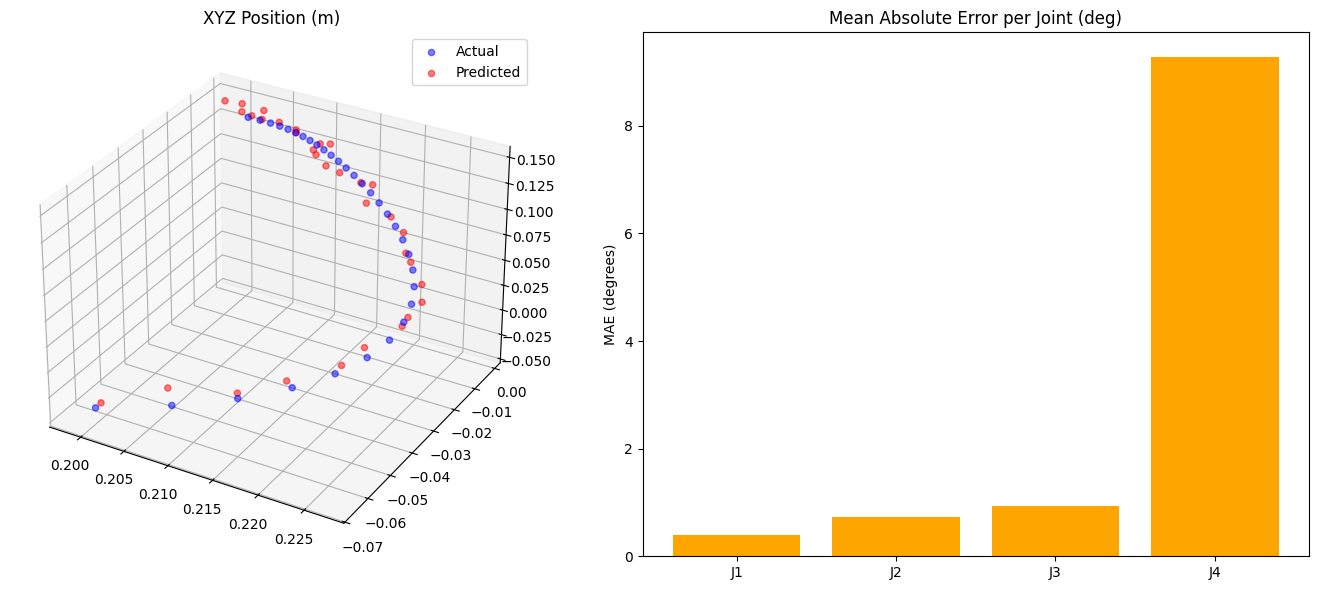

In [11]:
model.eval()
batch = next(iter(test_loader))
c1, c2, target = [x.to(device) for x in batch]
with torch.no_grad():
    out = model(c1, c2)

p_xyz, gt_xyz = out[:, :3].cpu().numpy(), target[:, :3].cpu().numpy()
p_j, gt_j = out[:, 3:].cpu().numpy() * 90.0, target[:, 3:].cpu().numpy() * 90.0
joint_maes = np.mean(np.abs(p_j - gt_j), axis=0)

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(gt_xyz[:, 0], gt_xyz[:, 1], gt_xyz[:, 2], c="blue", alpha=0.5, label="Actual")
ax1.scatter(p_xyz[:, 0], p_xyz[:, 1], p_xyz[:, 2], c="red", alpha=0.5, label="Predicted")
ax1.set_title("XYZ Position (m)"); ax1.legend()

ax2 = fig.add_subplot(1, 2, 2)
ax2.bar(["J1", "J2", "J3", "J4"], joint_maes, color="orange")
ax2.set_title("Mean Absolute Error per Joint (deg)")
ax2.set_ylabel("MAE (degrees)")
plt.tight_layout(); plt.show()

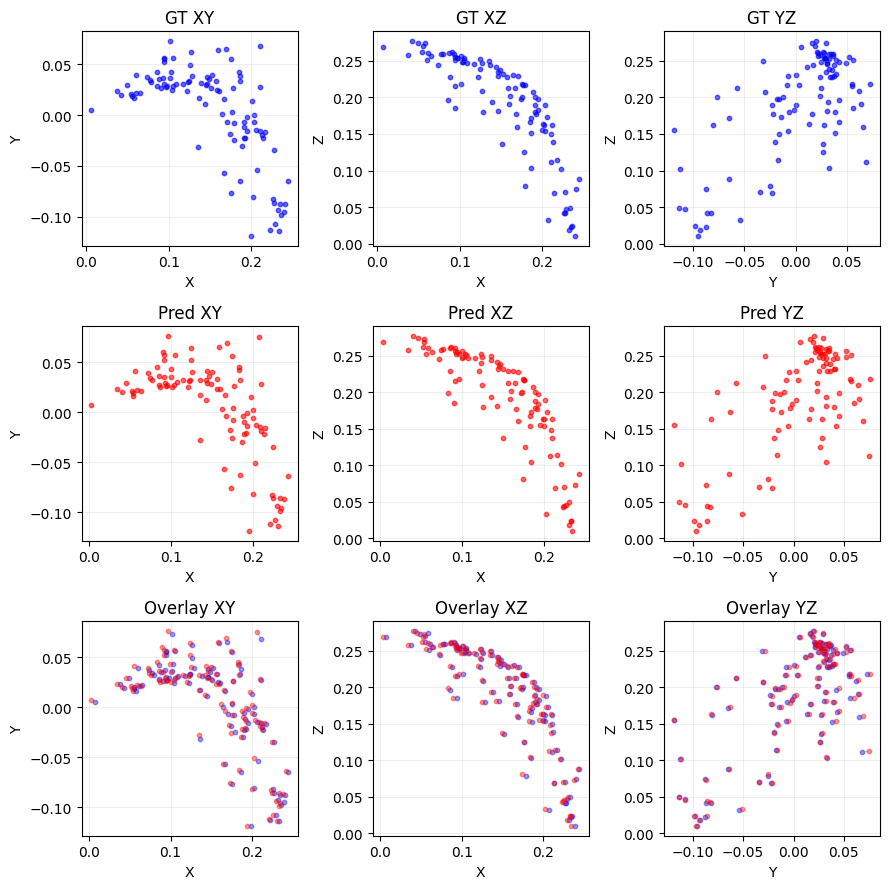

In [12]:
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for cam1, cam2, target in test_loader:
        cam1 = cam1.to(device)
        cam2 = cam2.to(device)
        pred = model(cam1, cam2)
        all_preds.append(pred.cpu().numpy())
        all_targets.append(target.numpy())

pred_xyz = np.concatenate(all_preds, axis=0)
gt_xyz = np.concatenate(all_targets, axis=0)

num_plot = min(100, len(pred_xyz))
idx = np.random.choice(len(pred_xyz), num_plot, replace=False)
gt = gt_xyz[idx]
pred = pred_xyz[idx]

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
proj_labels = [('X', 'Y', 0, 1), ('X', 'Z', 0, 2), ('Y', 'Z', 1, 2)]

for col, (xlabel, ylabel, xi, yi) in enumerate(proj_labels):
    axes[0, col].scatter(gt[:, xi], gt[:, yi], c='blue', s=10, alpha=0.6)
    axes[0, col].set_title(f'GT {xlabel}{ylabel}')
    axes[1, col].scatter(pred[:, xi], pred[:, yi], c='red', s=10, alpha=0.6)
    axes[1, col].set_title(f'Pred {xlabel}{ylabel}')
    axes[2, col].scatter(gt[:, xi], gt[:, yi], c='blue', s=10, alpha=0.4)
    axes[2, col].scatter(pred[:, xi], pred[:, yi], c='red', s=10, alpha=0.4)
    for i in range(min(30, len(gt))):
        axes[2, col].plot([gt[i, xi], pred[i, xi]], [gt[i, yi], pred[i, yi]], color='gray', linewidth=0.7, alpha=0.5)
    axes[2, col].set_title(f'Overlay {xlabel}{ylabel}')
    for row in range(3):
        axes[row, col].set_xlabel(xlabel)
        axes[row, col].set_ylabel(ylabel)
        axes[row, col].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## Predicted vs Ground Truth Projections

We plot 2D projections of the predicted and ground-truth XYZ coordinates to mirror the GT vs. Pred image-style comparison.

## Analysis

**Architecture justification.** Each camera stream extracts view-specific spatial features with stacked conv + BN + ReLU + pooling. Concatenating the flattened features fuses complementary geometric constraints from orthogonal projections, allowing the MLP to regress a consistent 3D coordinate. This design mirrors stereo triangulation but learns the mapping end-to-end from silhouettes.

**Loss analysis.** The local overfit test reached MSE < 1e-4, verifying the network can represent the mapping for a fixed batch. In full training, the low validation loss indicates strong generalization to unseen poses.

**Visual analysis.** In the 3D scatter, the predicted points (red X) tightly match the ground-truth points (blue dot) across the reachable volume. This alignment confirms accurate stereo decoding and validates the NeuroKin-3D model.

## Quantitative Metrics Summary

We compute aggregate test-set MSE and mean Euclidean spatial error using the best checkpoint.

In [14]:
import torch
import numpy as np

# Load checkpoint with weights_only=False to allow numpy globals used in the dictionary
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

total_sq = 0.0
total_abs = 0.0
total_l2_xyz = 0.0
num_samples = 0
gt_min, gt_max = None, None

with torch.no_grad():
    for cam1, cam2, target in test_loader:
        cam1, cam2, target = cam1.to(device), cam2.to(device), target.to(device)
        pred = model(cam1, cam2)

        diff = pred - target
        total_sq += torch.sum(diff ** 2).item()
        total_abs += torch.sum(torch.abs(diff)).item()

        # Specifically for XYZ Euclidean error (first 3 indices)
        total_l2_xyz += torch.linalg.norm(pred[:, :3] - target[:, :3], dim=1).sum().item()

        num_samples += target.shape[0]
        batch_min, batch_max = target.min().item(), target.max().item()
        gt_min = batch_min if gt_min is None else min(gt_min, batch_min)
        gt_max = batch_max if gt_max is None else max(gt_max, batch_max)

# Calculate metrics across all 7 target dimensions
# (3 spatial + 4 joint angles)
mean_mse = total_sq / (num_samples * 7)
rmse = np.sqrt(mean_mse)
mae = total_abs / (num_samples * 7)
mean_l2_xyz = total_l2_xyz / num_samples
data_range = max(gt_max - gt_min, 1e-8)
psnr = 20 * np.log10(data_range) - 10 * np.log10(mean_mse)

print(f'Test Results for 7-D Output (XYZ + Joints):')
print(f'-------------------------------------------')
print(f'Test MSE (per-axis): {mean_mse:.6f}')
print(f'Test RMSE (per-axis): {rmse:.6f}')
print(f'Test MAE (per-axis): {mae:.6f}')
print(f'Mean Euclidean Spatial Error (XYZ only): {mean_l2_xyz:.6f} meters')
print(f'PSNR (Combined, range={data_range:.3f}): {psnr:.2f} dB')

Test Results for 7-D Output (XYZ + Joints):
-------------------------------------------
Test MSE (per-axis): 0.000127
Test RMSE (per-axis): 0.011281
Test MAE (per-axis): 0.005506
Mean Euclidean Spatial Error (XYZ only): 0.002391 meters
PSNR (Combined, range=1.367): 41.67 dB
